Location Specific SOMs

In [93]:
#Necessary packages to load data
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from minisom import MiniSom
import sklearn_som
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sammon import sammon

Load in the data

In [94]:
base_dir =r"D:\ERA 5 Data\ERA5_Camden"

In [95]:
var_config = {
    # Original ERA5 variables
    
    "temp": {
        "folder": "Temp",
        "pattern": "era5_2mtemp__*.nc"
    },
    
    "u10": {
        "folder": "U Vector Wind",
        "pattern": "era5_uvector_*.nc"
    },
    
    "v10": {
        "folder": "V Vector Wind",
        "pattern": "era5_vvector_*.nc"
    },
    
    "sp": {
        "folder": "Surface Pressure",
        "pattern": "era5_sp__*.nc"
    },
    
    "dp": {
        "folder": "Dewpoint Temp",
        "pattern": "era5_2m_dew_temp__*.nc"
    },
    
    "k": {
        "folder": "K Index",
        "pattern": "era5_k_index_temp__*.nc"
    },
    
    "sol": {
        "folder": "Sol Rad",
        "pattern": "era5_surface_net_solar_radiation__*.nc"
    },
    # Calculated variables
    "rh": {
        "folder": "Relative Humidity",
        "pattern": "relative_humidity_*.nc"
    },

    "ws": {
        "folder": "Wind Speed",
        "pattern": "wind_speed_*.nc"
    },

    "hi": {
        "folder": "Heat Index",
        "pattern": "heat_index_*.nc"
    },

    "wb": {
        "folder": "Wet Bulb Temp",
        "pattern": "wet_bulb_temperature_*.nc"
    },
}

In [96]:
#Combine each year
def load_variable(var_name):
    config = var_config[var_name]

    path = os.path.join(base_dir, config["folder"], config["pattern"])

    ds = xr.open_mfdataset(
        path,
        combine="by_coords",
        parallel=False  
    )
    return ds

In [97]:
#To look at other variables raw data change what is in "" to any of the variables in block 3
ds = load_variable("temp")

print(ds)               # full structure
print(ds.variables)     # variables
print(ds.dims)          # dimensions
print(ds.attrs)         # metadata

<xarray.Dataset> Size: 190MB
Dimensions:     (valid_time: 184104, latitude: 14, longitude: 18)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 1MB 2004-01-01 ... 2024-12-31T23:...
  * latitude    (latitude) float64 112B 41.5 41.25 41.0 ... 38.75 38.5 38.25
  * longitude   (longitude) float64 144B -77.25 -77.0 -76.75 ... -73.25 -73.0
    expver      (valid_time) <U4 3MB dask.array<chunksize=(8784,), meta=np.ndarray>
Data variables:
    t2m         (valid_time, latitude, longitude) float32 186MB dask.array<chunksize=(8784, 14, 18), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-30T10:57 GRIB to CDM+CF via cfgrib-0.9.1...
Frozen({'t2m': <xarray.Variable (valid_time: 184104, lati

In [98]:
ds["t2m"].shape

(184104, 14, 18)

In [99]:
#Enter in the actual data variable title from the ERA5 data
ds.t2m

<xarray.DataArray 't2m' (valid_time: 184104, latitude: 14, longitude: 18)> Size: 186MB
dask.array<concatenate, shape=(184104, 14, 18), dtype=float32, chunksize=(8784, 14, 18), chunktype=numpy.ndarray>
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 1MB 2004-01-01 ... 2024-12-31T23:...
  * latitude    (latitude) float64 112B 41.5 41.25 41.0 ... 38.75 38.5 38.25
  * longitude   (longitude) float64 144B -77.25 -77.0 -76.75 ... -73.25 -73.0
    expver      (valid_time) <U4 3MB dask.array<chunksize=(8784,), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      252
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

Identify the Subset of Extreme Heat Days

datasets
    -> all original ERA5 data

processed_datasets
    -> warm-season, daily data

processed_extreme_datasets
    -> warm-season, daily data only on the 381 extreme dates

In [100]:
#Set city of interest lat and lon 

# Camden: 39.9259, -75.1196
# New Brunswick: 40.4862, -74.4518
# Philadelphia: 39.9526, -75.1652
# Newark: 40.7357, -74.1724
# Trenton: 40.2171, -74.7429
# Paterson: 40.9168, -74.1718
# Elizabeth: 40.6639, -74.2107
# Atlantic City: 39.3643, -74.4229
# Jersey City: 40.7178, -74.0431)

city_lat = 39.9259
city_lon = -75.1196

In [101]:
#Identify the extreme temperature days for the city of interest
city_temp = ds["t2m"].sel(latitude=city_lat, longitude=city_lon, method="nearest")

# Aggregate to daily maximum temperature and convert to a DataFrame
df_city = (city_temp.resample(valid_time="1D").max().to_dataframe(name="temp").reset_index().rename(columns={"valid_time": "date"}))

threshold = df_city["temp"].quantile(0.95)
extreme_days = df_city[df_city["temp"] >= threshold].copy()

In [114]:
# Convert extreme-day dates to daily timestamps
extreme_dates = pd.DatetimeIndex(extreme_days["date"]).normalize().unique()
print("95th percentile threshold:", threshold)
print("All extreme days:", len(extreme_dates))
print(extreme_days)

95th percentile threshold: 305.4949951171875
All extreme days: 384
           date  number  latitude  longitude        temp
160  2004-06-09       0      40.0      -75.0  306.310791
232  2004-08-20       0      40.0      -75.0  305.602539
524  2005-06-08       0      40.0      -75.0  306.384766
530  2005-06-14       0      40.0      -75.0  306.706299
556  2005-07-10       0      40.0      -75.0  305.989014
...         ...     ...       ...        ...         ...
7517 2024-07-31       0      40.0      -75.0  305.593262
7518 2024-08-01       0      40.0      -75.0  307.949463
7519 2024-08-02       0      40.0      -75.0  307.369385
7522 2024-08-05       0      40.0      -75.0  305.530518
7545 2024-08-28       0      40.0      -75.0  308.658691

[384 rows x 5 columns]


In [ ]:
# Keep only May through September
warm_extreme_dates = extreme_dates[extreme_dates.month.isin([5, 6, 7, 8, 9])]
# Make sure the dates are normalized to calendar days
warm_extreme_dates = pd.DatetimeIndex(warm_extreme_dates).normalize().unique()

print("Warm-season extreme days:", len(warm_extreme_dates))




Warm-season extreme days: 381


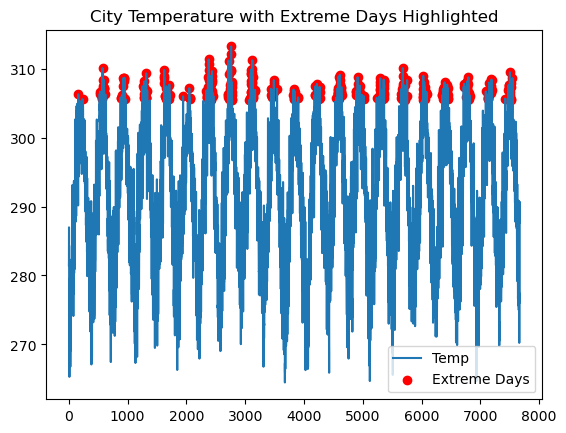

In [118]:
# Plot with extremes highlighted
plt.figure()
plt.plot(df_city.index, df_city["temp"], label="Temp")
plt.scatter(extreme_days.index, extreme_days["temp"], color="red", label="Extreme Days")
plt.legend()
plt.title("City Temperature with Extreme Days Highlighted")
plt.show()

Pull the matching "Extreme Days" from ERA5 data to prepare for the SOMs

In [105]:
# use variable titles from block 3: "u10", "v10" etc **ORDER MATTERS**
vars_to_use = ["temp"]

#Load datasets
datasets = {var: load_variable(var) for var in vars_to_use}

# Create an empty 2D (Rows & Columns) array to store the subset (May–Sept) + daily max
processed_datasets = {}

# Create a loop to iterate through the datasets and process them
for name, ds in datasets.items():

    var = next(iter(ds.data_vars))

    # May-Sept only with Boolean Mask
    ds_warm = ds.where(
        (ds.valid_time.dt.month >= 5) &
        (ds.valid_time.dt.month <= 9),
        drop=True
    )

    print(name, "after subset:", len(ds_warm.valid_time))

    # Daily aggregation
    ds_daily = (
        ds_warm
        .resample(valid_time="24h")
        .max()
    )
    ds_daily = ds_daily.dropna(dim="valid_time", how="all")

    processed_datasets[name] = ds_daily

    print(name, "after daily:", len(ds_daily.valid_time))

temp after subset: 77112
temp after daily: 3213


In [119]:
for name, ds in processed_datasets.items():
    print(name, len(ds.valid_time))

temp 3213


In [121]:
# Keep only warm-season extreme days
processed_extreme_datasets = {
    name: dataset.where(
        dataset.valid_time.dt.floor("D").isin(warm_extreme_dates),
        drop=True
    )
    for name, dataset in processed_datasets.items()
}

# Check the number of retained days
for name, dataset in processed_extreme_datasets.items():
    print(name, len(dataset.valid_time))


temp 381


In [124]:
#Normalize + flatten (only extreme subset)
normalized_datasets = {}
flattened_data = {}

for name, dataset in processed_extreme_datasets.items():

    var = next(iter(dataset.data_vars))
    group = dataset.groupby("valid_time.dayofyear")

    #Z-score normalization within each group: standardizes each variable by day-of-year 
    datasets_norm = group.map(
        lambda x: (
            (x - x.mean("valid_time")) /
            #handles cases where the standard deviation is zero by replacing it with 1 to avoid division by zero errors
            x.std("valid_time").where(x.std("valid_time") != 0, 1)
        )
    )

    normalized_datasets[name] = datasets_norm

    normalized_datasets[name] = datasets_norm

    flattened_data[name] = (
        datasets_norm[var]
        .stack(space=("latitude", "longitude"))
        .transpose("valid_time", "space")
    )

    print(name, flattened_data[name].shape)

temp (381, 252)


In [125]:
#Concatenate all flattened variables into a single DataArray along the 'space' dimension
#concatenation stacks data along one axis
X = xr.concat(list(flattened_data.values()), dim="space")

In [126]:
print(X.dims)
print(X.shape)

('valid_time', 'space')
(381, 252)


In [127]:
#MiniSom expects a2D numeric array and does operations like: X[row, :]
X = X.to_numpy()

In [128]:
# use the now Numpy array "X" for training the SOM
som = MiniSom(
    x=2,
    y=3,
    input_len=X.shape[1],
    sigma=np.sqrt(2**2 + 3**2),
    learning_rate=0.005,
    decay_function='linear_decay_to_zero',
    neighborhood_function='gaussian', 
    topology='rectangular',
    activation_distance='euclidean',
    random_seed=42
)

som.random_weights_init(X)
som.train_random(X, 35000, verbose=True) #iterations ≈ 10 × number_of_samples

 [ 35000 / 35000 ] 100% - 0:00:00 left 
 quantization error: 12.557730078721518


In [129]:
# Get the centers of the SOM nodes
#som.get_weights() returns the SOM unit weights. SOM weights are the representative vectors for each node in the SOM grid, capturing the patterns learned from the input data.
#SOM unit weights are stored in a 3D array with dimensions (x, y, input_len), where x and y are the dimensions of the SOM grid, and input_len is the number of features in the input data. Each weight vector represents the learned pattern for a specific node in the SOM grid.
#reshape(-1, X.shape[1]) flattens the 3D array into a 2D array where each row corresponds to a SOM node and each column corresponds to a feature in the input data. This allows for easier analysis and visualization of the learned patterns.
som_centers = som.get_weights().reshape(-1, X.shape[1])
print(som_centers)

#Get the labels for each input data point based on the trained SOM
# Loop over each row of X to find the winning node (Best Matching Unit) for each input vector. The som.winner(x) method returns the coordinates (row, col) of the winning node in the SOM grid for the input vector x.
som_labels = np.array([som.winner(x) for x in X]) #This gives (row,col)
print(som_labels[:10]) 

#Flatten the 2D coordinates of the winning nodes into a 1D array of labels. This is done by converting the (row, col) coordinates into a single index using the formula: index = row * number_of_columns + col. This allows for easier analysis and visualization of the SOM results.
# som.get_weights().shape[1] is the number of columns in the map, which is y
som_labels_flat = np.array([r * som.get_weights().shape[1] + c for r, c in som_labels])
print(som_labels_flat[:10])

[[-2.47961682e-01 -2.58129232e-01 -2.59379611e-01 ... -1.72783323e-01
  -1.52787637e-01 -1.50286008e-01]
 [-9.29653095e-02 -9.68557799e-02 -9.88544303e-02 ...  2.10707466e-02
   2.11631432e-02  1.78094852e-02]
 [ 8.09531968e-02  8.52382981e-02  8.25636310e-02 ...  2.28699362e-01
   2.09252745e-01  2.00518708e-01]
 [-9.01126878e-02 -9.65197401e-02 -9.46183254e-02 ... -2.00956054e-01
  -1.89290160e-01 -1.85939484e-01]
 [ 7.22464082e-02  7.22899267e-02  7.40558016e-02 ...  1.51483317e-04
  -6.94145585e-03 -8.26752414e-03]
 [ 2.40220286e-01  2.47907715e-01  2.49065624e-01 ...  2.05984553e-01
   1.82014001e-01  1.77196193e-01]]
[[1 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 2]
 [1 2]]
[3 3 0 4 0 0 0 0 5 5]


In [137]:
# Create DataFrame mapping time → node
# Use the time coordinate associated with the flattened extreme data
reference_dataset = next(iter(processed_extreme_datasets.values()))
times = pd.to_datetime(reference_dataset["valid_time"].values)
df_som = pd.DataFrame({
    'time': times,
    'node': som_labels_flat
})

# Set 'time' as the index
df_som.set_index('time', inplace=True)

node     0  1  2  3  4  5
time                     
2004-06  0  0  0  1  0  0
2004-08  0  0  0  1  0  0
2005-06  1  0  0  0  1  0
2005-07  4  0  0  0  0  2
2005-08  0  0  1  2  1  5


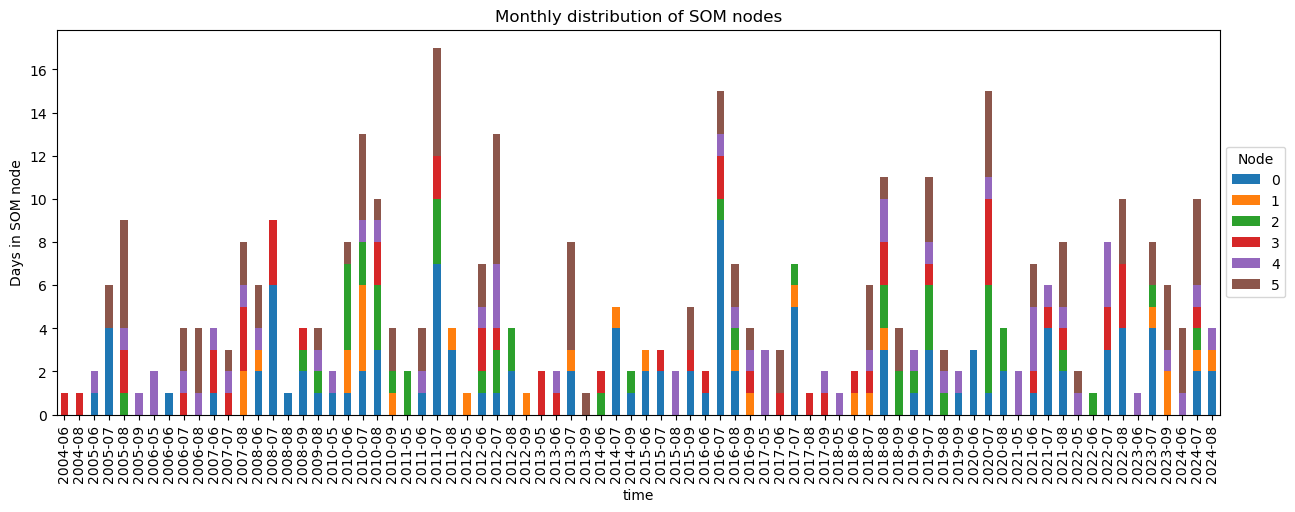

In [138]:
#Aggrgate nodes into months
# DAILY counts of each SOM node
daily_counts = df_som.groupby([df_som.index.date, 'node']).size().unstack(fill_value=0)

# MONTHLY counts of each SOM node
monthly_counts = df_som.groupby([df_som.index.to_period('M'), 'node']).size().unstack(fill_value=0)
print(monthly_counts.head())

# Plot monthly distribution 
monthly_counts.plot(kind='bar', stacked=True, figsize=(15,5))
plt.ylabel("Days in SOM node")
plt.title("Monthly distribution of SOM nodes")
plt.legend(title="Node", loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [140]:
#Find the exact days in a node of interest
#Identify node of interest
node_id = 4

times_in_node = df_som[df_som['node'] == node_id]

print(times_in_node.head())
print(f"\nTotal days in node {node_id}:", len(times_in_node))

dates_som = df_som.index[df_som['node'] == node_id].date

unique_days = np.unique(dates_som)
print(len(unique_days))

            node
time            
2005-06-14     4
2005-08-03     4
2005-09-13     4
2006-05-29     4
2006-05-30     4

Total days in node 4: 55
55


In [144]:
# Lookup SOM node at specific time 
query_time = pd.to_datetime("2005-09-13")
node_number = df_som.loc[query_time, 'node']
print(f"SOM node at {query_time}: {node_number}")

SOM node at 2005-09-13 00:00:00: 4


In [145]:
#HIT Map: the percentage of days in each month that fall into the node of interest
# Total days in the dataset
total_days = len(df_som)

# Days per node
node_dates = (
    df_som
    .groupby('node') 
    .apply(lambda x: x.index.date, include_groups=False) #x is a small DataFrame of only that cluster \ x.index = all timestamps in that cluster \.date removes the hour
)
# compute unique day counts,
days_per_node = (
    df_som
    .assign(date=df_som.index.date)
    .groupby('node')['date']
    .nunique()
)

# Percent of time
percent = (days_per_node / total_days) * 100

# Combine into one table
node_summary = pd.DataFrame({
    'Days': days_per_node,
    'Percent': percent.round(2)
})

print(node_summary)

      Days  Percent
node               
0      107    28.08
1       27     7.09
2       48    12.60
3       53    13.91
4       55    14.44
5       91    23.88


[[107  27  48]
 [ 53  55  91]]


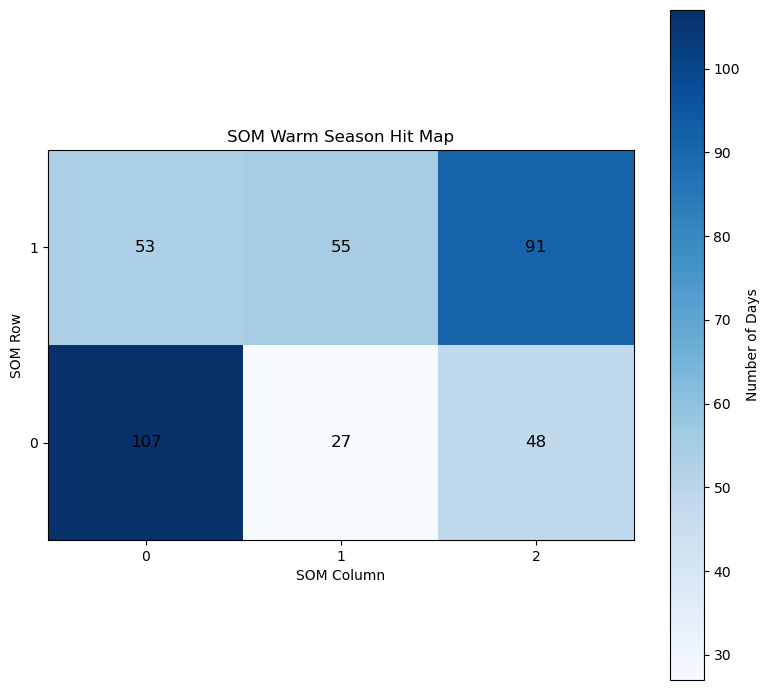

In [147]:
n_rows, n_cols = 2, 3 #Edit to the correct shape of the SOM grid

# Number of nodes
n_nodes = n_rows * n_cols

# Count observations assigned to each SOM node
hit_counts = pd.Series(som_labels_flat).value_counts()

# Make sure every node is included, even if it has 0 hits
hit_counts = hit_counts.reindex(
    range(n_nodes),
    fill_value=0
)

# Reshape into SOM grid
hit_map = hit_counts.values.reshape(n_rows, n_cols)

print(hit_map)
plt.figure(figsize=(8, 7))

plt.imshow(hit_map, origin="lower", cmap="Blues", interpolation="nearest")

plt.colorbar(label="Number of Days")

plt.xticks(range(n_cols))
plt.yticks(range(n_rows))

plt.xlabel("SOM Column")
plt.ylabel("SOM Row")
plt.title("SOM Warm Season Hit Map")

# Add number of observations to each node
for i in range(n_rows):
    for j in range(n_cols):
        plt.text(
            j,
            i,
            hit_map[i, j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.tight_layout()
plt.show()

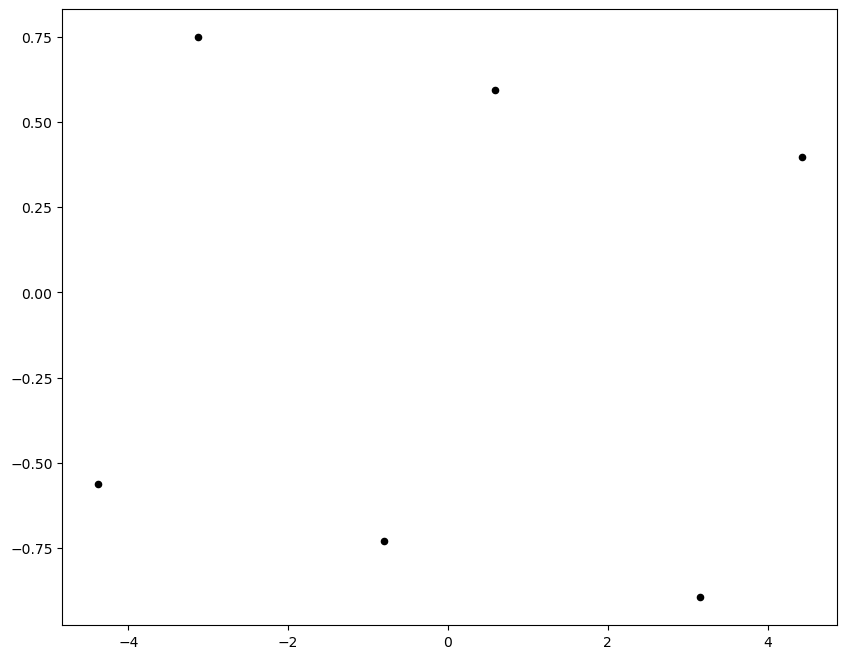

In [148]:
# Create a Sammon map
# A Sammon map is a type of nonlinear mapping technique used for dimensionality reduction and visualization of high-dimensional data. 
# It aims to preserve the pairwise distances between data points in the original high-dimensional space when projecting them onto a lower-dimensional space, typically two or three dimensions. 
# The goal is to create a visual representation that reflects the structure and relationships present in the original data.
weights = som.get_weights().reshape(-1, X.shape[1])
y, E = sammon.sammon(weights, 2, display=0)

# Plot Sammon map nodes: “Take each SOM node and place it in a 2D embedding space, then draw one black dot for each node.""
plt.figure(figsize=(10,8))
plt.scatter(y[:,0], y[:,1], s=20, c='black', marker='o')

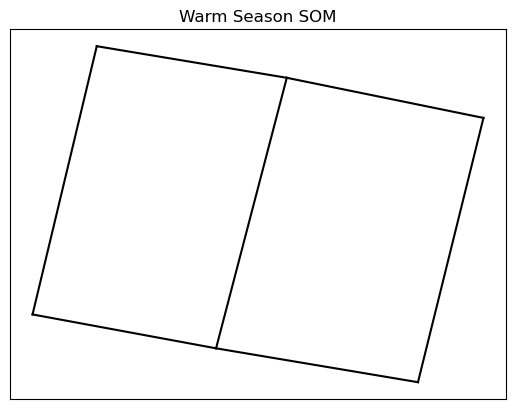

In [149]:
# Add lines between nodes
node_positions = np.reshape(y, (n_rows, n_cols, 2))
len_x, len_y, len_z = node_positions.shape

# add vertical lines
for i in range(len_x-1):
    for j in range(len_y):
        plt.plot(node_positions[i:i+2,j,0],node_positions[i:i+2,j,1],c='black')

# add horizontal lines
for i in range(len_x):
    for j in range(len_y-1):
        plt.plot(node_positions[i,j:j+2,0],node_positions[i,j:j+2,1],c='black')  

plt.xticks([])
plt.yticks([])
plt.title("Warm Season SOM", fontsize=12)
plt.show()

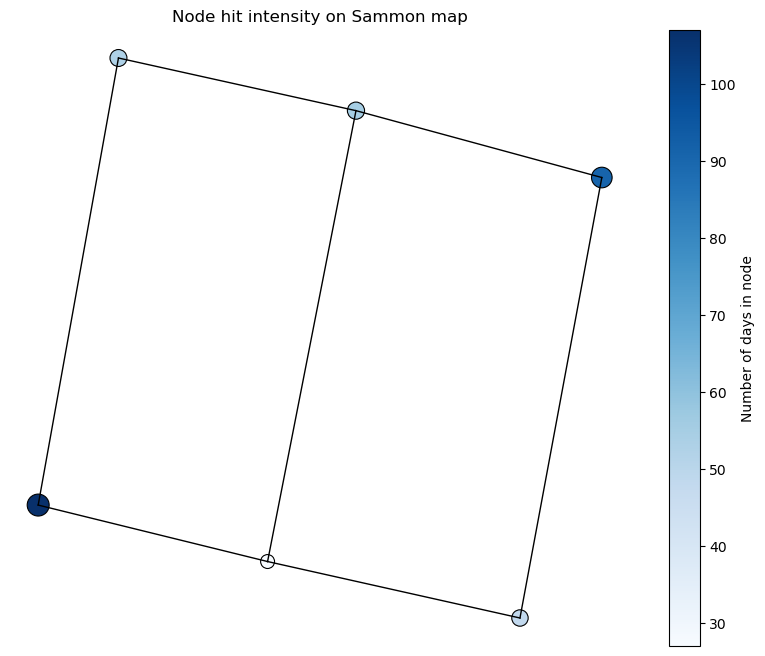

In [150]:
# node counts from your assignments
node_counts = (
    df_som["node"]
    .value_counts()
    .reindex(np.arange(n_rows * n_cols), fill_value=0)
    .to_numpy()
)

# reshape for plotting: (n_rows, n_cols, 2)
node_positions = y.reshape(n_rows, n_cols, 2)

# plot the Sammon embedding
fig, ax = plt.subplots(figsize=(10, 8))

# draw lines between nodes to show SOM topology
for i in range(n_rows - 1):
    for j in range(n_cols):
        ax.plot(
            node_positions[i:i+2, j, 0],
            node_positions[i:i+2, j, 1],
            c="black",
            linewidth=1
        )

for i in range(n_rows):
    for j in range(n_cols - 1):
        ax.plot(
            node_positions[i, j:j+2, 0],
            node_positions[i, j:j+2, 1],
            c="black",
            linewidth=1
        )

# flatten node positions for a single scatter call
flat_positions = node_positions.reshape(-1, 2)
flat_sizes = 50 + 200 * (node_counts / node_counts.max())

sc = ax.scatter(
    flat_positions[:, 0],
    flat_positions[:, 1],
    s=flat_sizes,
    c=node_counts,
    cmap="Blues",
    edgecolors="black",
    linewidths=0.8
)
fig.colorbar(sc, ax=ax, label="Number of days in node")
ax.set_title("Node hit intensity on Sammon map")
ax.set_axis_off()
plt.show()

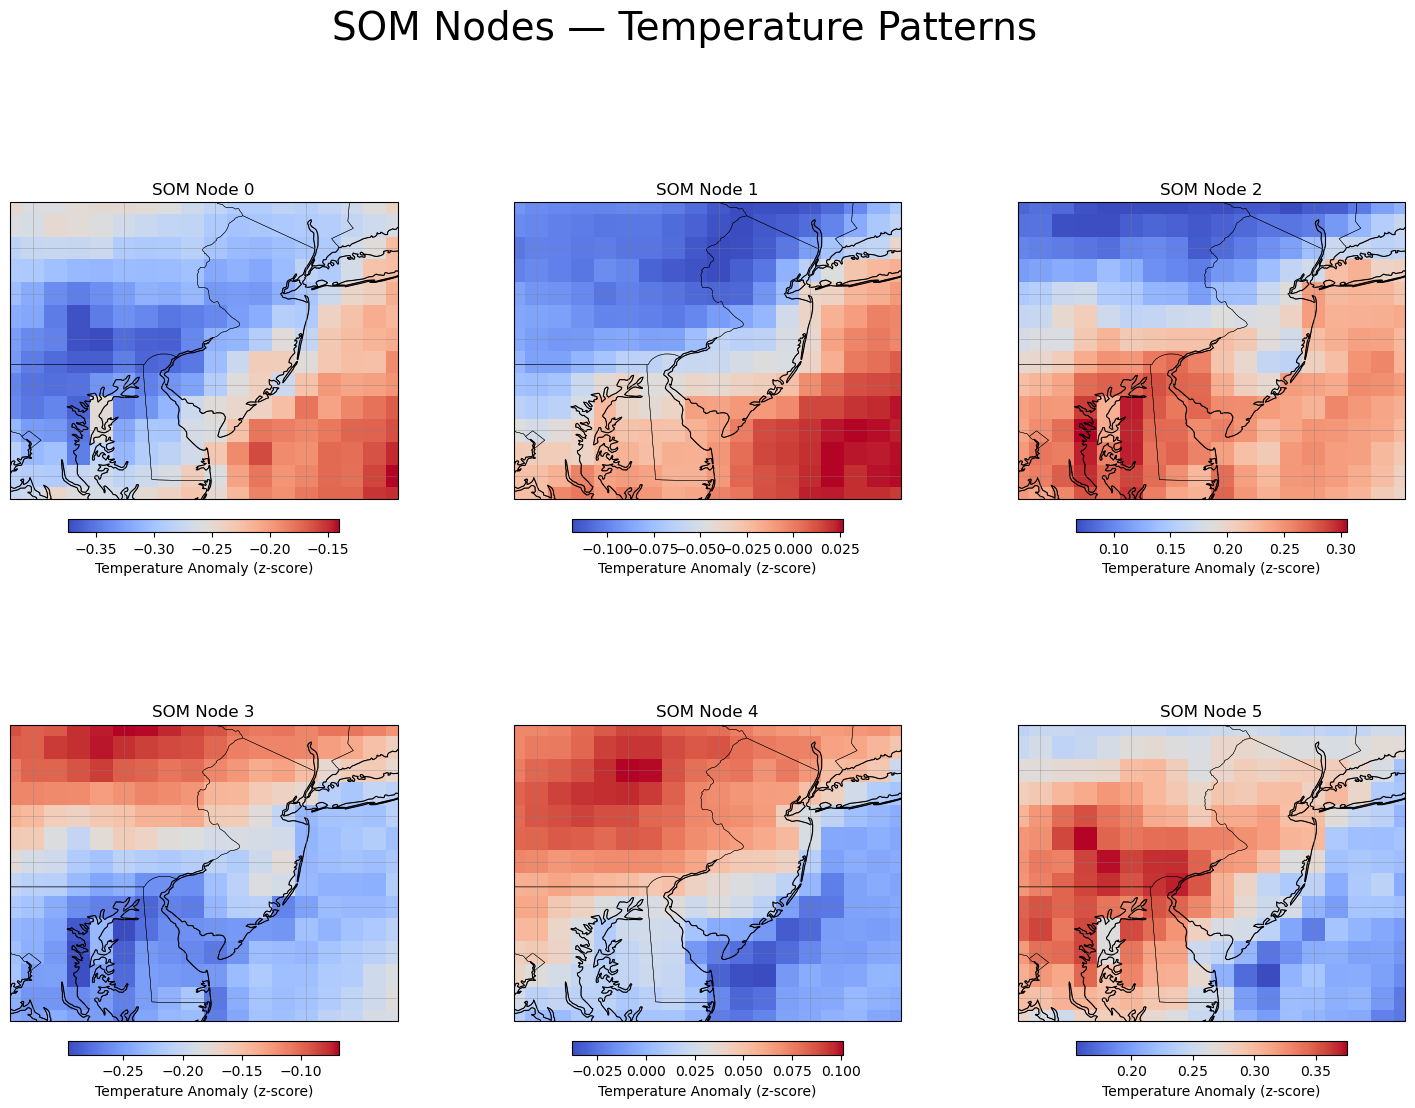

In [151]:
#Visualize the Meterological patterns for each SOM node
lats = ds['latitude'].values
lons = ds['longitude'].values

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 6 * n_rows),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = np.array(axes).flatten()

for i, ax in enumerate(axes[:len(som_centers)]):
    
    # reshape: (variables, lat, lon)
    cluster_map = som_centers[i].reshape(1, len(lats), len(lons))
    
    # --- Pressure (z-score) ---
    im = ax.pcolormesh(
        lons, lats,
        cluster_map[0],
        cmap='coolwarm',
        transform=ccrs.PlateCarree()
    )
    
    # map features
    ax.coastlines(resolution='10m', color='black', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=0.3)
    ax.set_title(f"SOM Node {i}", fontsize=12)
    ax.set_extent([lons.min(), lons.max(), lats.min(), lats.max()])
    ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5)

    # colorbar per subplot
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal",
                        pad=0.05, shrink=0.7)
    cbar.set_label('Temperature Anomaly (z-score)')

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.suptitle('SOM Nodes — Temperature Patterns', fontsize=28, y=1.02)

plt.show()